In [77]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
# Standard imports
import os
# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
# Local imports

In [79]:
sns.set()  

# Load Data
Loading iris dataset using scit-learn's dataset

In [80]:
data=datasets.load_iris()

In [81]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [82]:
data["data"][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [83]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [84]:
data["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [85]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

# Purpose
We are trying to use the sepal length and width along side the pedal length and width to predict if it is a setosa , versicolor or virginica flower

# Create Pandas DataFrame from Data
We could use NumPy and Numpy array for this particular analysis but we will make a Data Frame Using Pandas for practice 

In [86]:
df =pd.DataFrame(data["data"], columns=data['feature_names'])

In [87]:
df ["target"]=data["target"]

In [88]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Basic descriptive statistics

In [89]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Distributions of features and target

Text(0.5, 0.98, 'Histogram of sepal length (cm)')

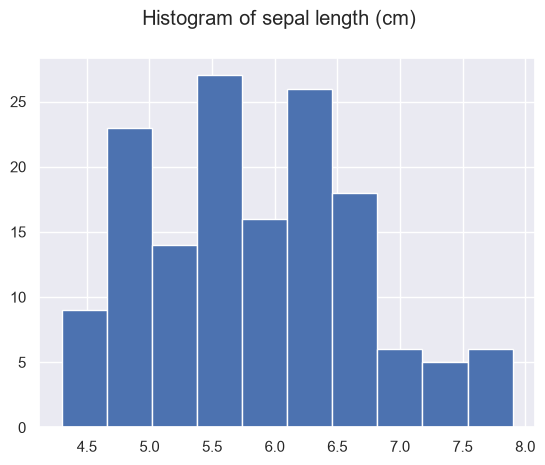

In [90]:
col="sepal length (cm)"
df [col].hist()
plt.suptitle(f"Histogram of {col}")

Text(0.5, 0.98, 'Histogram of petal width (cm)')

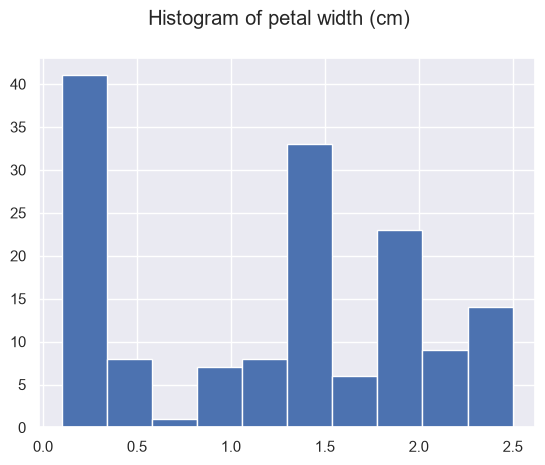

In [91]:
col="petal width (cm)"
df [col].hist()
plt.suptitle(f"Histogram of {col}")

Text(0.5, 0.98, 'Histogram of petal length (cm)')

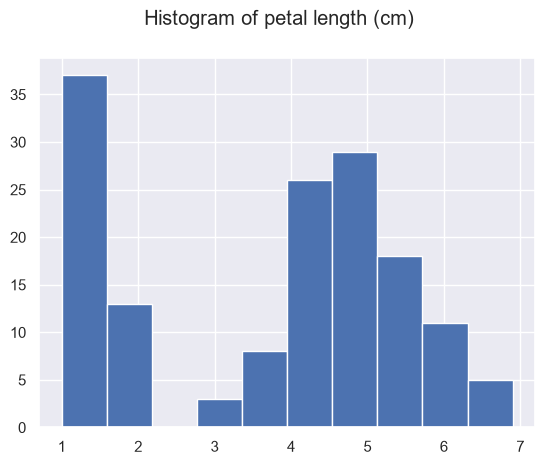

In [92]:
col="petal length (cm)"
df [col].hist()
plt.suptitle(f"Histogram of {col}")

Text(0.5, 0.98, 'Histogram of petal width (cm)')

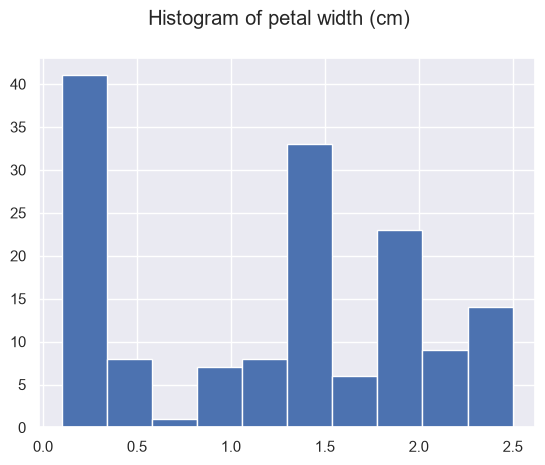

In [93]:
col="petal width (cm)"
df [col].hist()
plt.suptitle(f"Histogram of {col}")

# Relationship with the data features with the target

In [94]:
#Create new column with species names
df["target_name"] = df["target"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

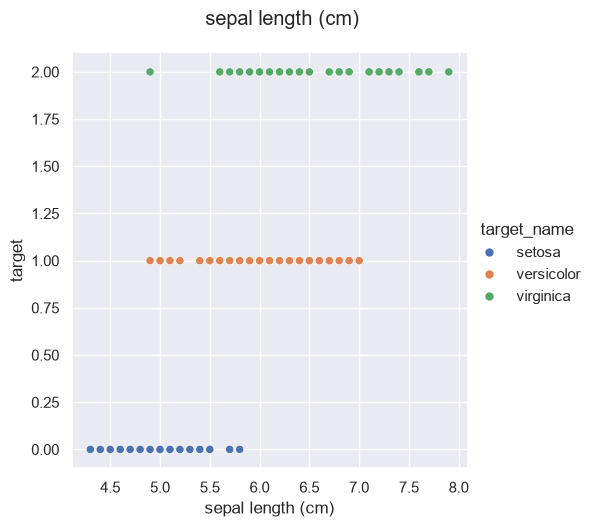

In [95]:
col="sepal length (cm)"
sns.relplot(x=col, y="target", hue="target_name", data=df)
_= plt.suptitle(col,y=1.05)

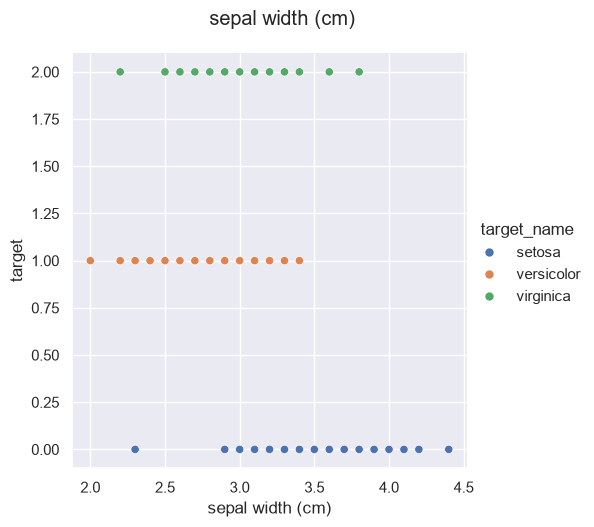

In [96]:
col="sepal width (cm)"
sns.relplot(x=col, y="target", hue="target_name", data=df)
_= plt.suptitle(col,y=1.05)

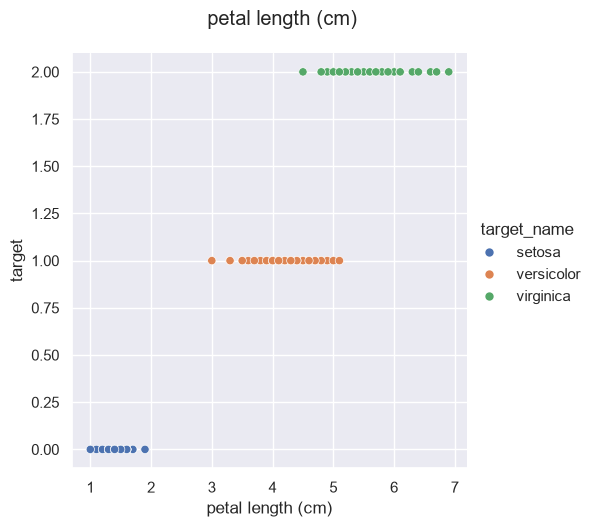

In [97]:
col="petal length (cm)"
sns.relplot(x=col, y="target", hue="target_name", data=df)
_= plt.suptitle(col,y=1.05)

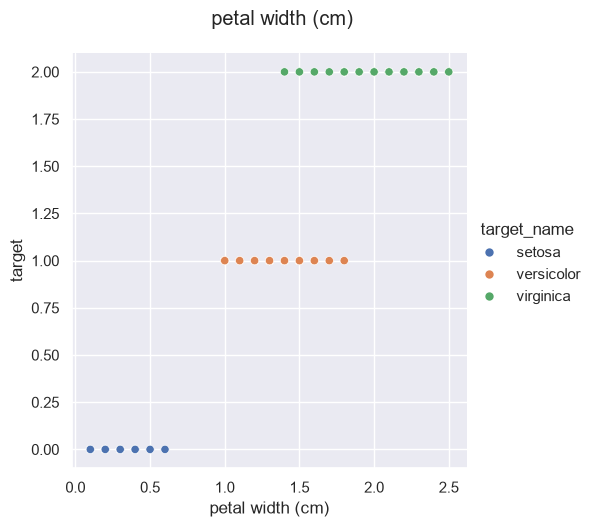

In [98]:
col="petal width (cm)"
sns.relplot(x=col, y="target", hue="target_name", data=df)
_= plt.suptitle(col,y=1.05)

# Exploratory Data Analysis Pairplots

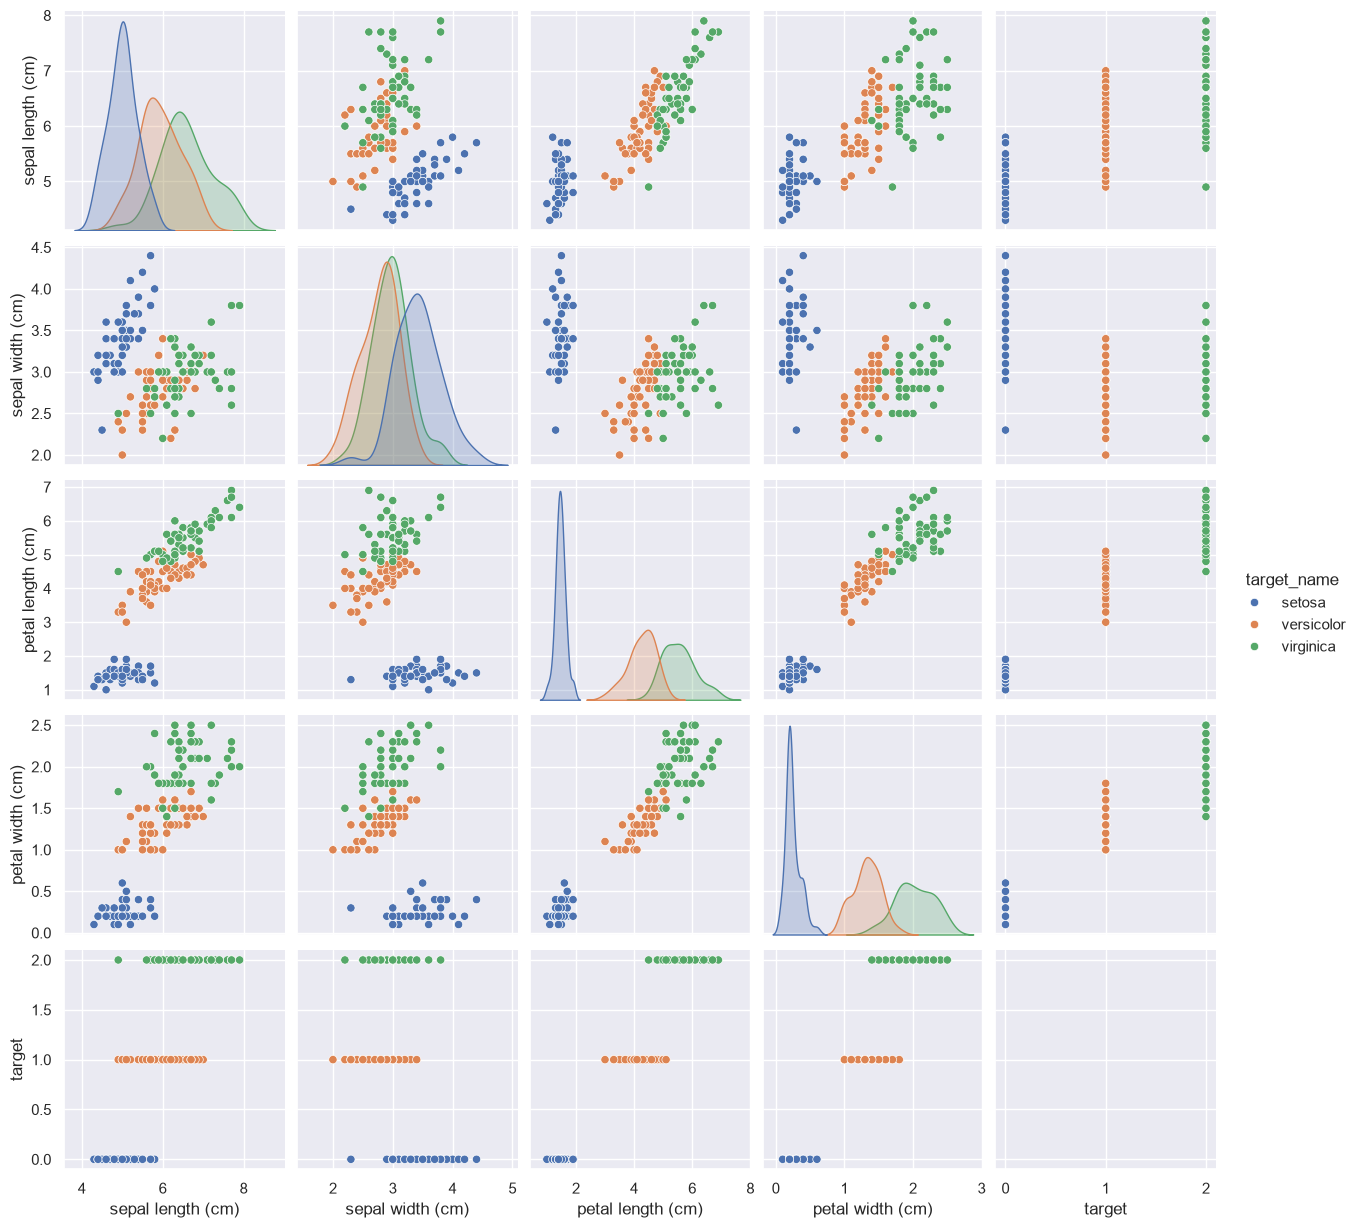

In [99]:
sns.pairplot(df, hue="target_name")

# Train Set Split
You always want to evaluate your final model on a different set than the ones used for training
(exept for cross evaluation)

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
df_train, df_test = train_test_split(df, test_size=0.25)

In [102]:
df_train.shape

(112, 6)

In [103]:
df_test.shape

(38, 6)

In [104]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
67,5.8,2.7,4.1,1.0,1,versicolor
110,6.5,3.2,5.1,2.0,2,virginica
33,5.5,4.2,1.4,0.2,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor
145,6.7,3.0,5.2,2.3,2,virginica


# Prepare our data for modeling
This involes splitting the data back out into NumPy arrays

In [105]:
X_train = df_train.drop(columns=["target", "target_name"]).values #inplace=True, to modify the original data
y_train = df_train["target"].values

# What is our baseline ?

What is the simplest model we can think of ?

In this case if our baseline mode is just guessing randomly we would expect to have a accuracy of 33.33% (since we have 3 evenly balanced classes)

So our models should at least beat 33.33% accuracy

# Modeling - Simple manual model

Let's manually look at our data and decide some cutoff points for classification

In [106]:
def single_feature_prediction(pedal_length):
    """Predicts the Iris species given the petal length"""
    if pedal_length < 2.5:
        return 0
    elif pedal_length < 4.8:
        return 1
    else:
        return 2

In [107]:
X_train

array([[5.8, 2.7, 4.1, 1. ],
       [6.5, 3.2, 5.1, 2. ],
       [5.5, 4.2, 1.4, 0.2],
       [6.7, 3.1, 4.4, 1.4],
       [6.7, 3. , 5.2, 2.3],
       [5.6, 3. , 4.1, 1.3],
       [5.7, 3. , 4.2, 1.2],
       [6.4, 3.2, 4.5, 1.5],
       [5.7, 2.9, 4.2, 1.3],
       [6.4, 2.7, 5.3, 1.9],
       [5. , 2. , 3.5, 1. ],
       [5.5, 2.6, 4.4, 1.2],
       [5. , 3.4, 1.6, 0.4],
       [6.5, 3. , 5.5, 1.8],
       [4.9, 3.6, 1.4, 0.1],
       [5.7, 2.6, 3.5, 1. ],
       [5.6, 3. , 4.5, 1.5],
       [5.2, 2.7, 3.9, 1.4],
       [4.4, 3. , 1.3, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.7, 3.8, 1.7, 0.3],
       [5. , 3. , 1.6, 0.2],
       [5.9, 3. , 4.2, 1.5],
       [5.1, 3.5, 1.4, 0.2],
       [5.6, 2.9, 3.6, 1.3],
       [5.8, 2.7, 5.1, 1.9],
       [6. , 2.9, 4.5, 1.5],
       [5.5, 3.5, 1.3, 0.2],
       [5.1, 3.8, 1.9, 0.4],
       [5.9, 3. , 5.1, 1.8],
       [5. , 3.4, 1.5, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [4.8, 3. , 1.4, 0.1],
       [7.1, 3. , 5.9, 2.1],
       [6. , 2

In [108]:
manual_y_predictions = np.array([single_feature_prediction(val) for val in X_train[:, 2]])

In [109]:
manual_model_accuracy = np.mean(manual_y_predictions == y_train)

In [110]:
print(f"Manual model accuracy: {manual_model_accuracy *100:.2f}%")

Manual model accuracy: 95.54%


# Modeling Logistic Regression

In [111]:
from sklearn.linear_model import LogisticRegression

### Using a validaiton set to evaluate our model 

In [112]:
model=LogisticRegression(max_iter=2000)

In [113]:
# Xt stands for "X_train" and Xv stands for "X_validation". yt and yv are the corresponding labels.
Xt, Xv, yt, yv = train_test_split(X_train, y_train, test_size=0.25)

In [114]:
model.fit(Xt, yt)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [115]:
y_pred = model.predict(Xv)

In [116]:
model.score(X_train, y_train) # You never want to evaluate your model on the training data, but we will do it here for demonstration purposes.


0.9642857142857143

In [117]:
model.score(Xv, yv) # This is the correct way to evaluate your model, using the validation data.

1.0

# Using Cross Validation to validate our model

In [118]:
from sklearn.model_selection import cross_val_score , cross_val_predict

In [119]:
model = LogisticRegression(max_iter=2000)

In [120]:
accuracies = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")


In [121]:
np.mean(accuracies)

np.float64(0.9731225296442687)

# Where are we missclassifying points

In [122]:
y_pred=cross_val_predict(model, X_train, y_train, cv=5)

In [123]:
predicted_correctly_mask = y_pred == y_train

In [124]:
X_train[predicted_correctly_mask]

array([[5.8, 2.7, 4.1, 1. ],
       [6.5, 3.2, 5.1, 2. ],
       [5.5, 4.2, 1.4, 0.2],
       [6.7, 3.1, 4.4, 1.4],
       [6.7, 3. , 5.2, 2.3],
       [5.6, 3. , 4.1, 1.3],
       [5.7, 3. , 4.2, 1.2],
       [6.4, 3.2, 4.5, 1.5],
       [5.7, 2.9, 4.2, 1.3],
       [6.4, 2.7, 5.3, 1.9],
       [5. , 2. , 3.5, 1. ],
       [5.5, 2.6, 4.4, 1.2],
       [5. , 3.4, 1.6, 0.4],
       [6.5, 3. , 5.5, 1.8],
       [4.9, 3.6, 1.4, 0.1],
       [5.7, 2.6, 3.5, 1. ],
       [5.6, 3. , 4.5, 1.5],
       [5.2, 2.7, 3.9, 1.4],
       [4.4, 3. , 1.3, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.7, 3.8, 1.7, 0.3],
       [5. , 3. , 1.6, 0.2],
       [5.9, 3. , 4.2, 1.5],
       [5.1, 3.5, 1.4, 0.2],
       [5.6, 2.9, 3.6, 1.3],
       [5.8, 2.7, 5.1, 1.9],
       [6. , 2.9, 4.5, 1.5],
       [5.5, 3.5, 1.3, 0.2],
       [5.1, 3.8, 1.9, 0.4],
       [5.9, 3. , 5.1, 1.8],
       [5. , 3.4, 1.5, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [4.8, 3. , 1.4, 0.1],
       [7.1, 3. , 5.9, 2.1],
       [5.4, 3

In [125]:
not_predicted_correctly_mask=~predicted_correctly_mask

In [126]:
not_predicted_correctly_mask

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [127]:
X_train[not_predicted_correctly_mask]

array([[6. , 2.7, 5.1, 1.6],
       [6. , 3. , 4.8, 1.8],
       [5.9, 3.2, 4.8, 1.8]])

In [128]:
df_predictions= df_train.copy()

In [129]:
df_predictions["correct_prediction"] = predicted_correctly_mask

In [130]:
df_predictions["prediction"] = y_pred

In [131]:
df_predictions["predicted_label"] = df_predictions["prediction"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [132]:
df_predictions.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,correct_prediction,prediction,predicted_label
67,5.8,2.7,4.1,1.0,1,versicolor,True,1,versicolor
110,6.5,3.2,5.1,2.0,2,virginica,True,2,virginica
33,5.5,4.2,1.4,0.2,0,setosa,True,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor,True,1,versicolor
145,6.7,3.0,5.2,2.3,2,virginica,True,2,virginica


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

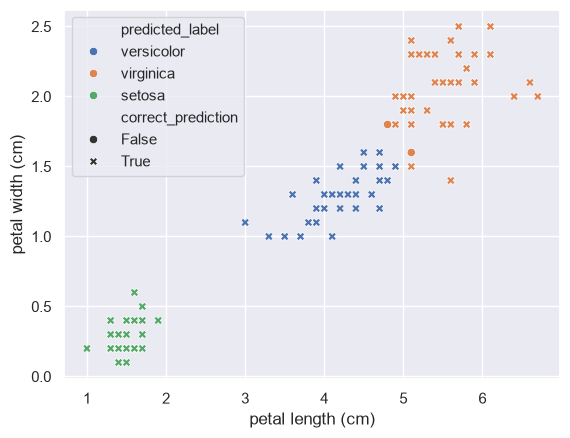

In [133]:
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="predicted_label", style="correct_prediction", data=df_predictions)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

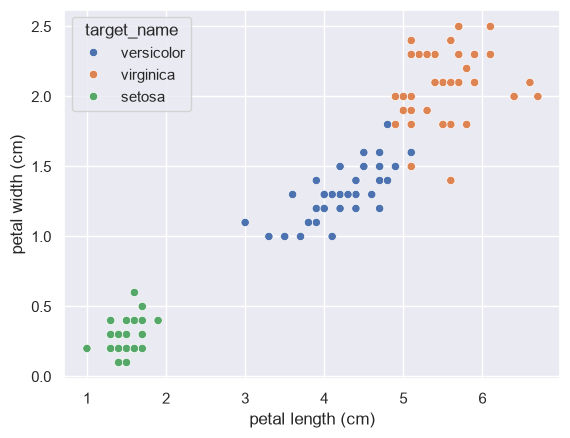

In [134]:
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="target_name", data=df_predictions)

In [135]:
def plot_incorrect_predictions(df_predictions, x_axis_feature, y_axis_feature):
    """Plots the incorrect predictions of the model"""
    fig , axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.flatten()
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="predicted_label", data=df_predictions, ax=axs[0])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="target_name", data=df_predictions, ax=axs[1])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue="correct_prediction", data=df_predictions, ax=axs[2])
    axs[3].set_visible(False)
        

    plt.show()

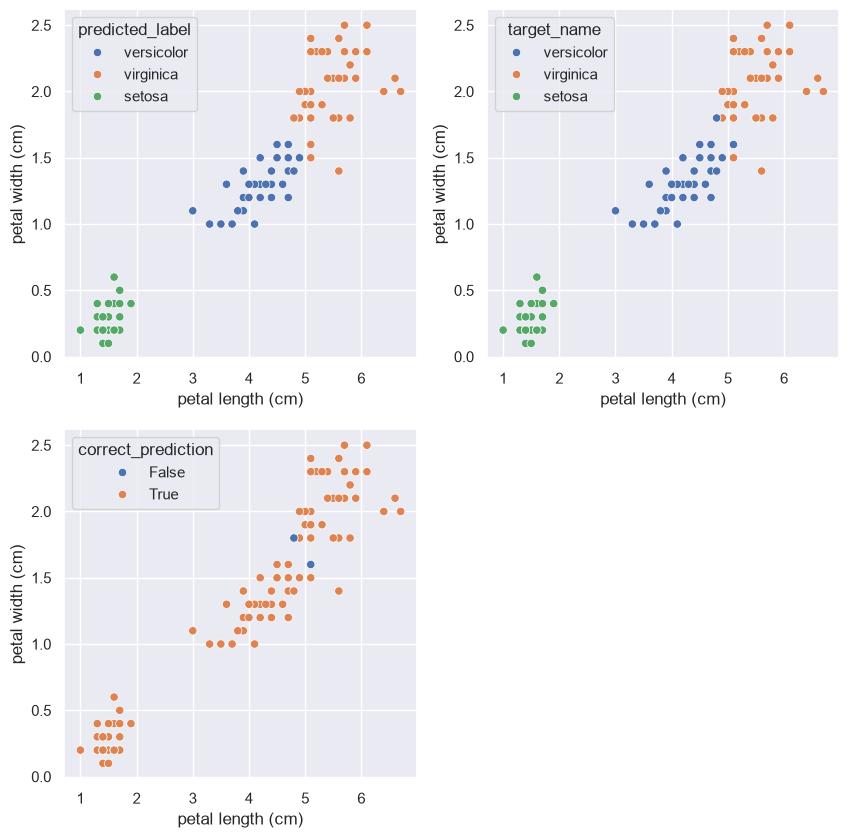

In [136]:
plot_incorrect_predictions(df_predictions, "petal length (cm)", "petal width (cm)")

# Model Tuning
What is model tuning?
Model tuning is trying to determine the parameters of your model (hyperparamiters)

In [137]:
for reg_parm in [1, 1.3, 1.8, 2 ,2.3 , 2.9, 3]:
    print (reg_parm)
    model = LogisticRegression(max_iter=2000, C=reg_parm)
    accuracies = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"accuracy: {np.mean(accuracies) *100:.2f}%")

1
accuracy: 97.31%
1.3
accuracy: 97.31%
1.8
accuracy: 96.40%
2
accuracy: 96.40%
2.3
accuracy: 96.40%
2.9
accuracy: 96.40%
3
accuracy: 96.40%


# Final Model

In [138]:
model = LogisticRegression(max_iter=2000, C=2)

# How well our model performs on on the test Set

In [139]:
x_test = df_test.drop(columns=["target", "target_name"]).values
y_test = df_test["target"].values

In [140]:
x_test.shape

(38, 4)

In [141]:
y_test

array([2, 1, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0,
       0, 0, 1, 2, 0, 2, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1])

### Train our final model using our Full Traing Dataset

In [142]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [143]:
y_test_pred=model.predict(x_test)

In [144]:
test_set_currectly_classified = y_test_pred == y_test
test_set_accuracy = np.mean(test_set_currectly_classified)

In [145]:
print (f"Test set accuracy: {np.mean(test_set_accuracy) *100:.2f}%")

Test set accuracy: 92.11%


In [146]:
test_set_currectly_classified

array([ True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [147]:
df_predictions_test= df_test.copy()
df_predictions_test["correct_prediction"] = test_set_currectly_classified
df_predictions_test["prediction"] = y_test_pred
df_predictions_test["predicted_label"] = df_predictions_test["prediction"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [148]:
df_predictions_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,correct_prediction,prediction,predicted_label
129,7.2,3.0,5.8,1.6,2,virginica,True,2,virginica
62,6.0,2.2,4.0,1.0,1,versicolor,True,1,versicolor
48,5.3,3.7,1.5,0.2,0,setosa,True,0,setosa
49,5.0,3.3,1.4,0.2,0,setosa,True,0,setosa
117,7.7,3.8,6.7,2.2,2,virginica,True,2,virginica


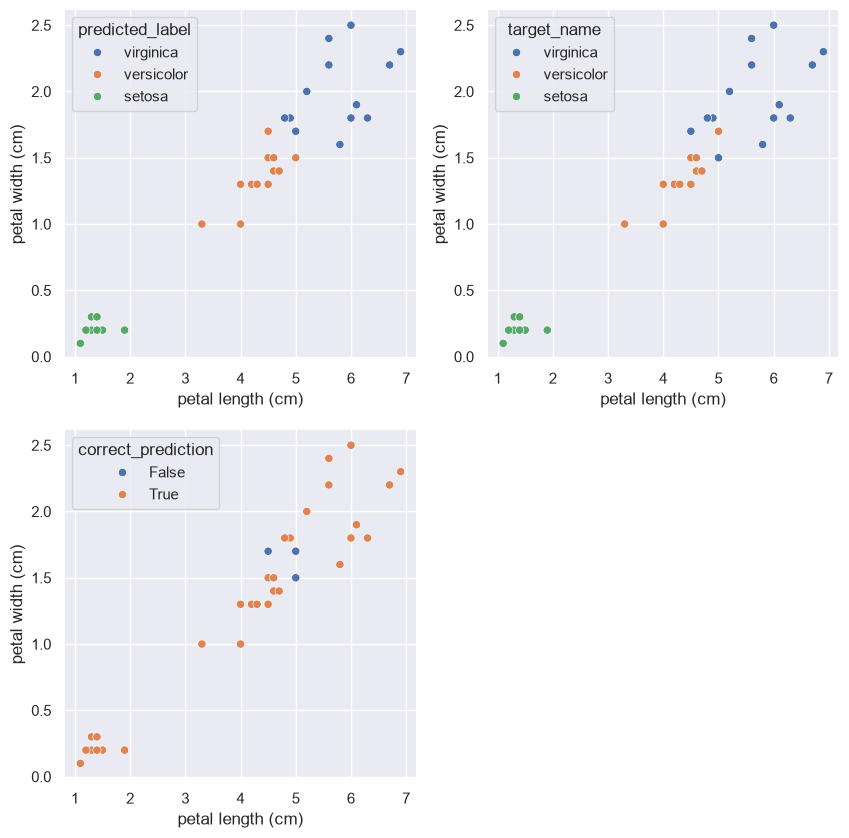

In [149]:
plot_incorrect_predictions(df_predictions=df_predictions_test, x_axis_feature="petal length (cm)", y_axis_feature="petal width (cm)")

# In coclusion 
In coclusion , we achieved a 92.11% accuracy on the data set